<a href="https://colab.research.google.com/github/MaysNassar/prediction-of-product-sales/blob/main/prediction_of_product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# prediction of product sales


- Author: Mays Nassar

## Project Overview

This dataset was collected by BigMart in 2013 and contains sales data for 1,559 products across 10 outlets in different cities. Each product and outlet has specific attributes that may influence sales performance.

The goal of this project is to build a predictive model that can estimate the sales of each product at a particular outlet. By doing so, BigMart aims to better understand which properties of products and stores play the most important role in driving sales.

In this notebook, we will start by loading and inspecting the data, then clean it by handling missing values and fixing inconsistencies, followed by exploratory data analysis to uncover patterns and insights in the data.

## Data Dictionary

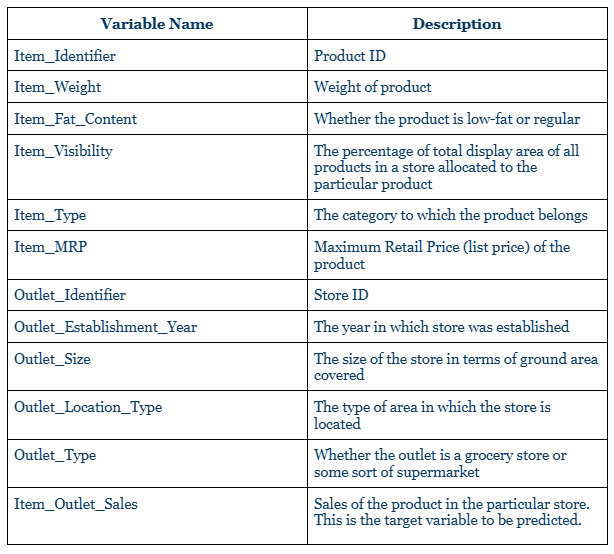

## Load and Inspect Data

### Import Libraries and Mount Drive

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [193]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [194]:
path = '/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df_org = pd.read_csv(path)
df_org.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [195]:
df= df_org.copy()

### Inspect the data

In [196]:
# check th data informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [197]:
df.shape

(8523, 12)

`There are **8523** rows and **12** columns`

### Duplicated Data

In [198]:
# checking the data type
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


* there is a
 7 object, 4 float and 1 int**

In [199]:
#check for duplicted data
# by saving the filter
duplicated_rows = df.duplicated()
duplicated_rows.sum()

np.int64(0)

* There is no duplicates

## Clean Data


### Handling Missing Values

In [200]:
# identify missing value
df.isna()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [201]:
# count the total number of null value for each col
null_sum = df.isna().sum()
null_sum

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [202]:
# Identifying the percentage of null values
df.isna().sum() / len(df) * 100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


* There are 1463 missing values in Item_Weight column (17.16%)
* There are 1463 missing values in 2410 Outlet_Size column (28.27%)


In [203]:
df[df['Item_Identifier']== 'FDA15'][['Item_Identifier', 'Item_Weight']]

,Item_Identifier,Item_Weight
0,FDA15,9.3
831,FDA15,9.3
2599,FDA15,9.3
2643,FDA15,9.3
4874,FDA15,9.3
5413,FDA15,9.3
6696,FDA15,NaN
7543,FDA15,9.3


In [204]:
#
df[df['Item_Identifier']== 'FDP10'][['Item_Identifier', 'Item_Weight']]

,Item_Identifier,Item_Weight
7,FDP10,NaN
585,FDP10,19.0
2623,FDP10,19.0
3382,FDP10,19.0
4585,FDP10,19.0
6087,FDP10,19.0
7883,FDP10,19.0


* now we can see that the item FDP10 has the same weight across all rows and so on, every item has the same identefier has the same weight

In [205]:
df['Item_Weight'] = df['Item_Weight'].fillna(df.groupby('Item_Identifier')['Item_Weight'].transform('mean'))


In [206]:
df['Item_Weight'].isna().sum()

np.int64(4)

In [207]:
# fill the 4 null value with the median of the column
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())

In [208]:
# lets check if there is any null values
df['Item_Weight'].isna().sum()

np.int64(0)


*   Since `Outlet_Size` is categorical and 28% of values are missing, dropping rows would lose too much data,so filling with the mode preserves the dataset while making a reasonable assumption about the most common store size.





In [209]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [210]:
# first get the mode
outlet_size_mode = df['Outlet_Size'].mode()[0]
# then we fill the null value with the mode
df['Outlet_Size'] = df['Outlet_Size'].fillna(outlet_size_mode)


In [211]:
# now confirming that there is no null values
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


### Fixing Data Type
- We will now address the data types and make sure that they match the data dictionary.

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Inspecting Categorical Columns & Addressing Inconsistent Values

- We will create a filter for object columns , then we will create a for loop to loops through all object columns so we can inspect them further

In [213]:
# identify string columns
str_cols = df.select_dtypes(include='object').columns
str_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [214]:
for col in str_cols:
  print(df[col].value_counts())
  print('\n')

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: cou

After further inspection, there are inconsistancies with spelling categories in `Item_Fat_Content`

*   LF should be Low Fat  
*   reg should be Regular
*   low fat should be Low Fat

  We will address these inconsistencies using .replace to replace the inconsistent categories




In [215]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [216]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'reg':'Regular','LF':'Low Fat', 'low fat':'Low Fat'})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


* now verify that all of the inconsistent values in that column have been addressed.

### Summary Statistics for Numeric Features


*  we will use df.describe() to view the summary statistics for the numeric features

In [217]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.875314,0.066132,140.992782,1997.831867,2181.288914
std,4.645010,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.785000,0.026989,93.826500,1987.000000,834.247400
50%,12.650000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [218]:
df.describe().round(3)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000,8523.000,8523.000,8523.000,8523.000
mean,12.875,0.066,140.993,1997.832,2181.289
std,4.645,0.052,62.275,8.372,1706.500
min,4.555,0.000,31.290,1985.000,33.290
25%,8.785,0.027,93.826,1987.000,834.247
50%,12.650,0.054,143.013,1999.000,1794.331
75%,16.850,0.095,185.644,2004.000,3101.296
max,21.350,0.328,266.888,2009.000,13086.965


* lookup the `mean` ,`minimum `, `maximum` value for each numeric columns

In [219]:
statistics = df.describe()
statistics.loc[['mean','min', 'max']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
mean,12.875314,0.066132,140.992782,1997.831867,2181.288914
min,4.555000,0.000000,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Data Analysis

Checking the data info

In [220]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [222]:
df['Item_Identifier'].value_counts()

,count
Item_Identifier,
FDW13,10
FDG33,10
FDX31,9
FDT07,9
NCY18,9
...,...
FDO33,1
FDK57,1
FDT35,1


### Heat Map Correlations

In [223]:
# Define numeric columns
num_cols = df.select_dtypes('number').columns
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [224]:
corr = df[num_cols].corr()
corr.round(3)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000,-0.009,0.026,-0.013,0.013
Item_Visibility,-0.009,1.000,-0.001,-0.075,-0.129
Item_MRP,0.026,-0.001,1.000,0.005,0.568
Outlet_Establishment_Year,-0.013,-0.075,0.005,1.000,-0.049
Item_Outlet_Sales,0.013,-0.129,0.568,-0.049,1.000


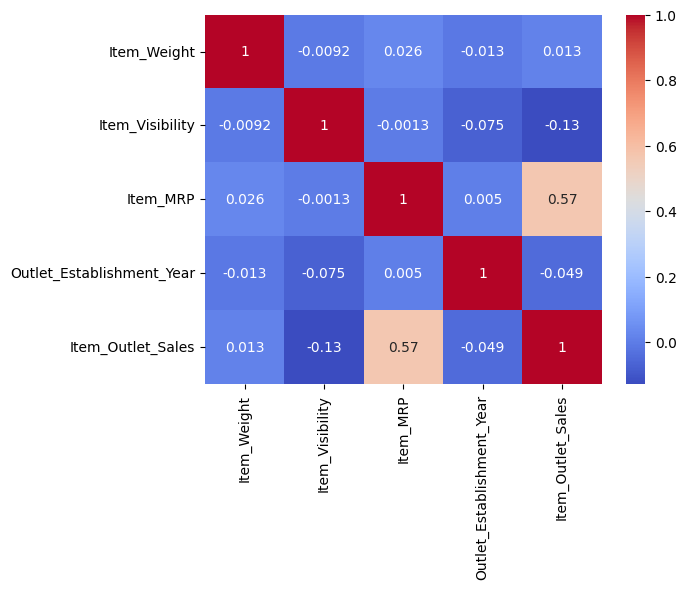

In [225]:
# Make a heatmap of correlations

sns.heatmap(corr, cmap= 'coolwarm', annot= True);

-  There is a strong relation between Item_MRP and Item_Outlet_Sales (0.57) , thats mean the higher the price, the higher the sales revenue.
- There is a weak relation between Item_Visibility and Item_Outlet_Sales (-0.13)
- all other features show very weak or no correlation with sales

- For each numeric feature, we will plot the distribution and a boxplot.

### UNIVARIATE Plotting Functions For EDA






In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df_org.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticks(ax.get_xticks())
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)

   #get the mean and median
  mean = round(df[x].mean(),2)
  median = round(df[x].median(),2)

  # Annotating measures of centrality
  axes[0].axvline(mean, color='red',label=f'Mean: {mean}', lw=2)
  axes[0].axvline(median, color='green', label= f'Median: {median}',
             ls='--', lw=2)

  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  axes[0].legend(loc='upper right')
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

### Multivariate Plotting Functions VS. Numeric TARGET


In [245]:
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df_org.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks())
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4)):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

### Visualizing Numerical Features

#### Item_Weight

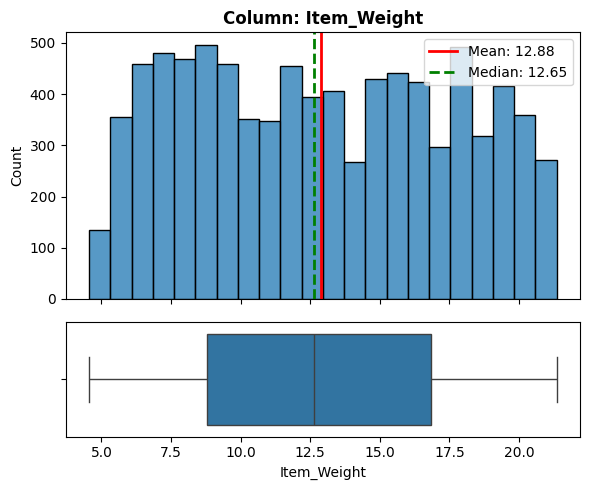

- NaN's Found: 0 (0.0%)
- Unique Values: 446
- Most common value: '12.15' occurs 105 times (1.23%)
- Not constant or quasi-constant.


In [242]:
# call the columns
explore_numeric(df, 'Item_Weight');


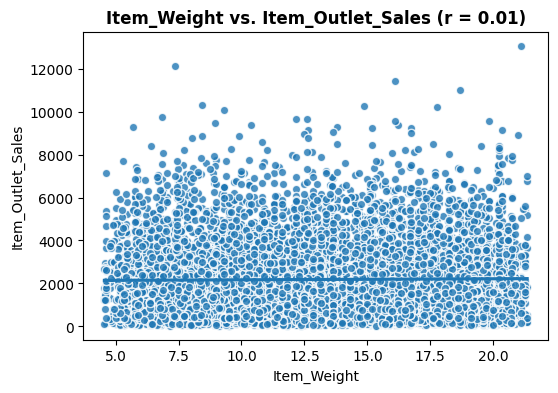

In [246]:
plot_numeric_vs_target(df, 'Item_Weight');

- The boxplot confirms that item weights are evenly distributed with no outliers

#### Item_Visibility


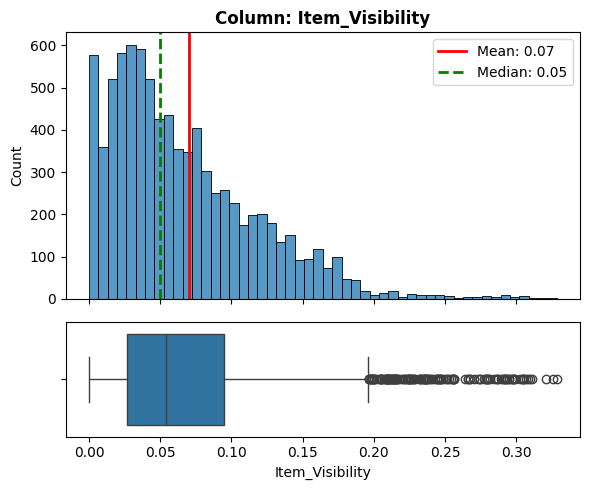

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [228]:
explore_numeric(df, 'Item_Visibility');


- The distribution is right-skewed
- the box is pushed to the left with many outliers on the right side, meaning there's a few item with high visibility

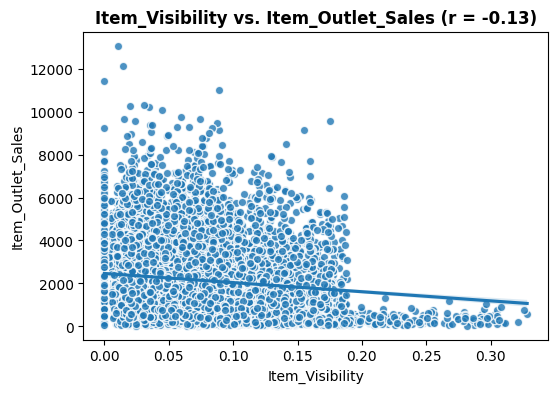

In [247]:
plot_numeric_vs_target(df, 'Item_Visibility');

#### Item_MRP

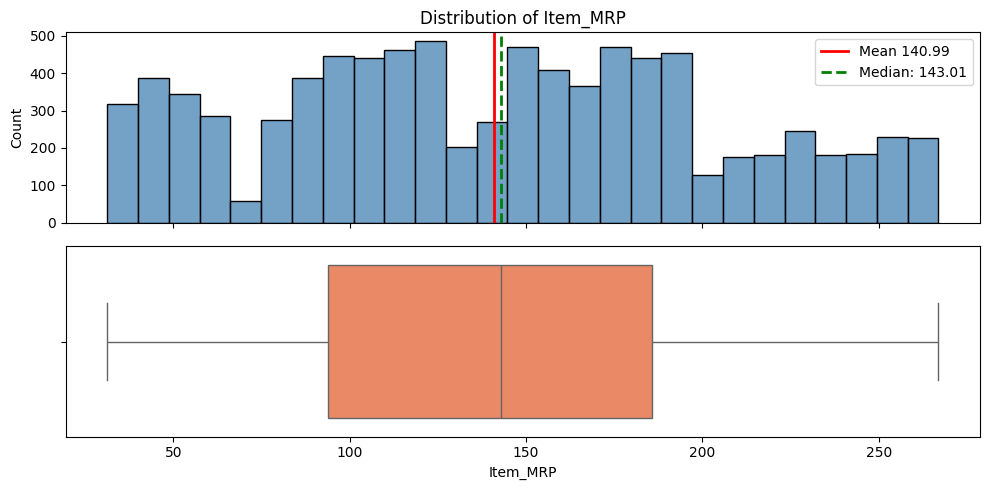

In [229]:
plot_numeric(df, 'Item_MRP');


- we can see in histograms that the price distribution is in 4 groubs, meaning the market sells the item at 4 different level.
- The boxplot shows prices are widely spread across the full range with no outliers.

#### Item_Outlet_Sales

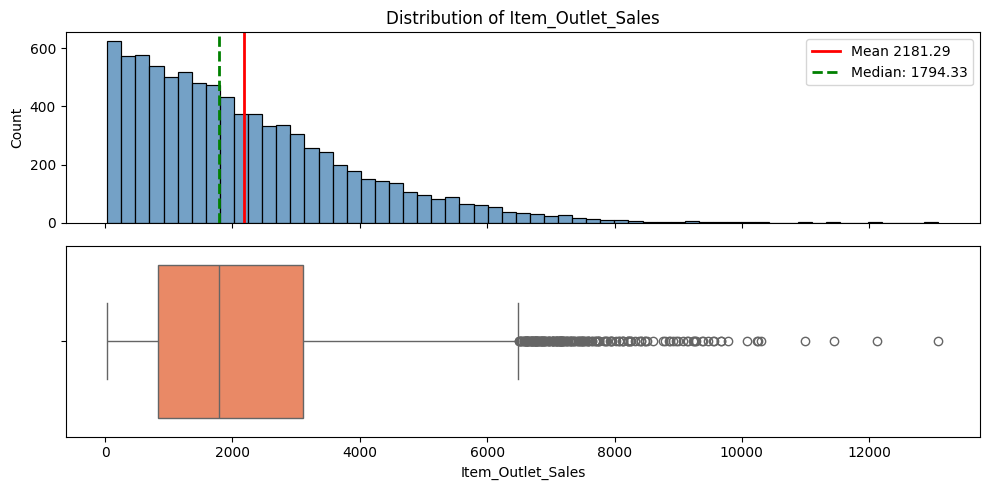

In [230]:
plot_numeric(df, 'Item_Outlet_Sales');

- The distribution is right-skewed meaning :
  - Most product have low sale (under $2000)
  - Small number of product have higher sale or are top seller.
- The boxplots shows the outliers means a few item are top seller  

### Visualizing Categorical Features




In [231]:
object_cols = df.select_dtypes('object').columns
object_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

#### Item_Fat_Content

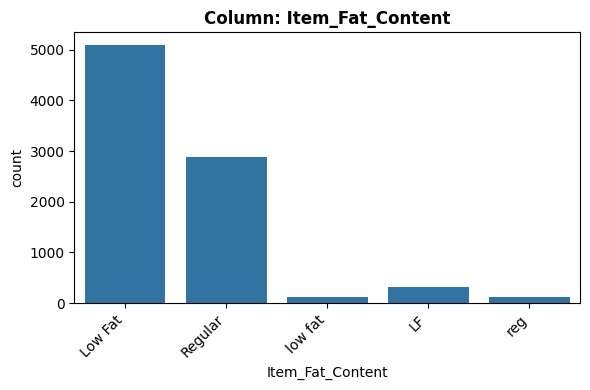

- NaN's Found: 0 (0.0%)
- Unique Values: 5
- Most common value: 'Low Fat' occurs 5089 times (59.71%)
- Not constant or quasi-constant.


In [232]:
explore_categorical(df, 'Item_Fat_Content');

- Low fat products are higher than regular

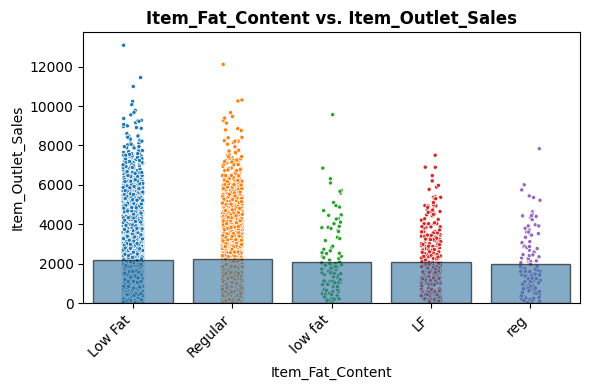

In [248]:
plot_categorical_vs_target(df, 'Item_Fat_Content');

#### Item Type

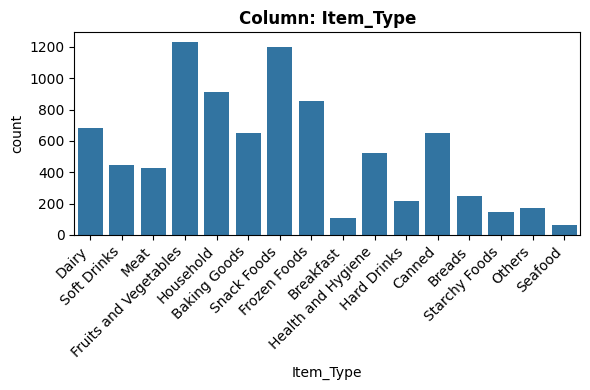

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [233]:
explore_categorical(df, 'Item_Type');

- Most shown items are Fruits and Vegetables and Snak foods (over 1200 )
- Least shown item are Breakfasts and Seafood

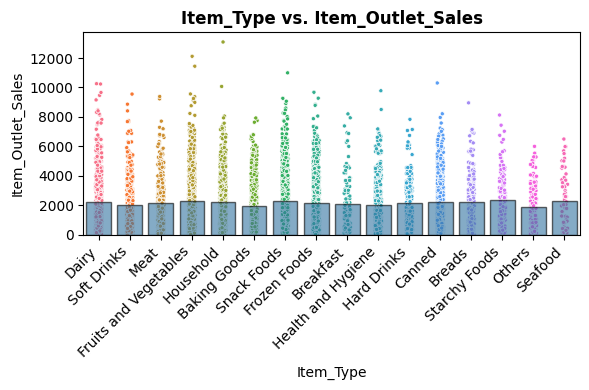

In [249]:
plot_categorical_vs_target(df, 'Item_Type');

#### Outlet_Size

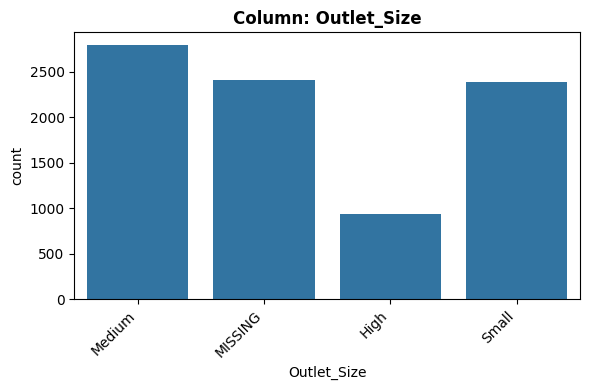

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [234]:
explore_categorical(df, 'Outlet_Size');


- Medium sized outlets are most common size
- This means BigMarts operates mostly in medium sized stores.

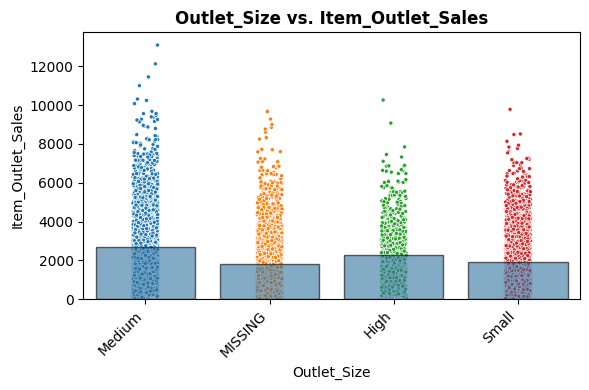

In [250]:
plot_categorical_vs_target(df, 'Outlet_Size');

#### Outlet_Location_Type

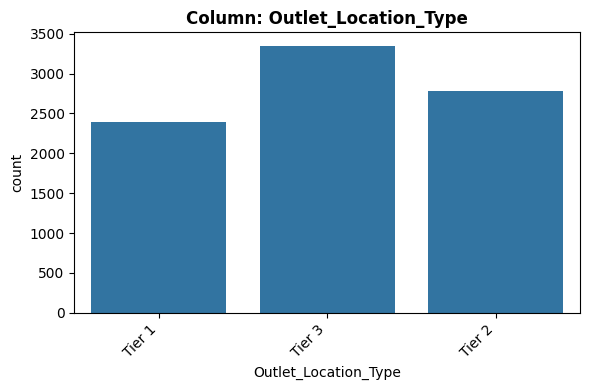

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [235]:
explore_categorical(df, 'Outlet_Location_Type');


- Tier 3 locations have the most outlets, followed by Tier 2 and Tier 1.
- This means BigMart has more stores in smaller cities than in big cities

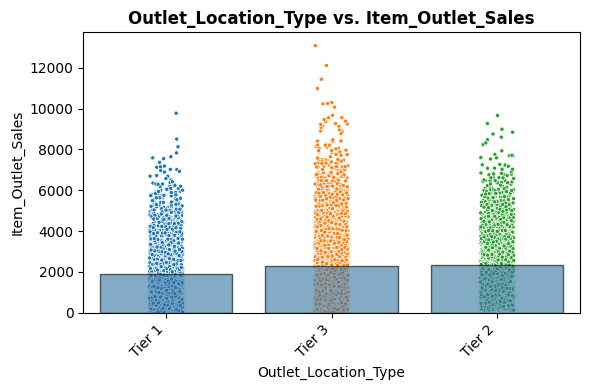

In [251]:
plot_categorical_vs_target(df, 'Outlet_Location_Type');

#### Outlet_Type

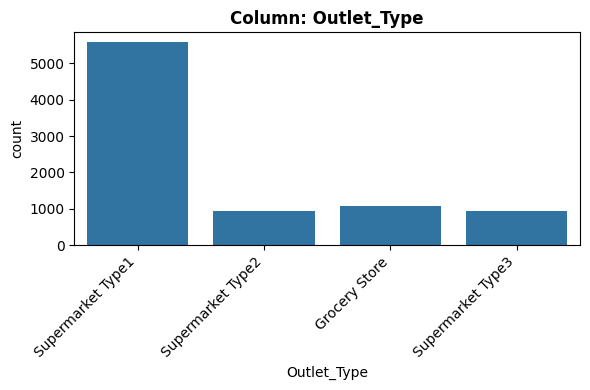

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [236]:
explore_categorical(df, 'Outlet_Type');

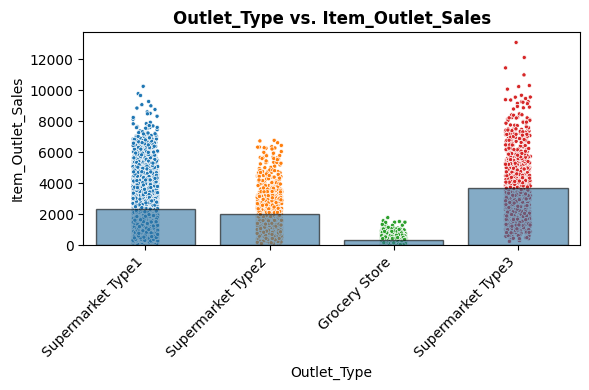

In [252]:
plot_categorical_vs_target(df, 'Outlet_Type');

#### plot 'Item_Type' with 'Item_Fat_Content'

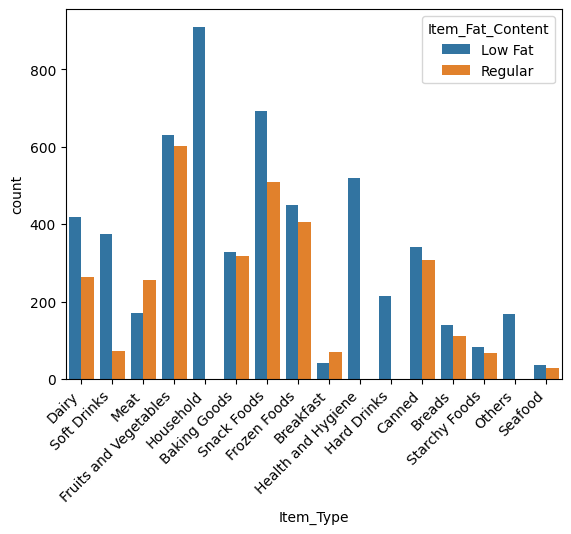

In [238]:
ax =sns.countplot(data=df, x='Item_Type', hue='Item_Fat_Content')
plt.xticks(rotation=45, ha='right');

- Household and Health & Hygiene products only come in Low Fat.
- Most items types have more Low Fat products than Regular.
- Least common item in tha data is seafood.


## Feature Inspection

</strong><ul><li>What type of feature is it? (Categorical (nominal), ordinal, numeric)</li></ul><ul><li>How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)</li><li>Is the feature constant or quasi-constant?</li><li>What is the cardinality? Is it high (&gt;10)?</li><li>Would we know this feature <strong>before</strong> the target is determined?</li><li>Is there a business case/understanding reason to exclude based on our business case?</li></ul></li><li><strong>

- Based on your business understanding, would you expect this feature to be a predictor of the target?
- Does this feature appear to be a predictor of the target?